<a href="https://colab.research.google.com/github/kaifkh20/d2l/blob/main/linear_regression_from_scratch_d2l3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [83]:
!pip install d2l --no-deps

In [84]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l
from torch import nn

the w and b used to produce Synthetic Data is not related to w^ and b^ that will be used to train example

SyntheticData is used to test the model training like if we know the relationship : y=2x+3

so if the model doesnt train close to that then there is a problem

In [85]:
torch.manual_seed(100009)
class SyntheticRegressionData(d2l.DataModule):
  def __init__(self,w,b,noise=0.01,num_train=1050,num_val=1050,batch_size=32):
    super().__init__()
    self.save_hyperparameters()
    n = num_train+num_val
    self.X = torch.randn(n,len(w))
    noise = torch.randn(n,1) * noise
    self.y = torch.matmul(self.X, w.reshape((-1,1))) + b + noise

This gives a relationship of:

`y = 2x1​+(−3.4x2​)=−6.8x1​x2`


In [86]:
data = SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)



```
@d2l.add_to_class(SyntheticRegressionData)
def get_dataloader(self, train):
    if train:
        indices = list(range(0, self.num_train))
        # The examples are read in random order
        random.shuffle(indices)
    else:
        indices = list(range(self.num_train, self.num_train+self.num_val))
    for i in range(0, len(indices), self.batch_size):
        batch_indices = torch.tensor(indices[i: i+self.batch_size])
        yield self.X[batch_indices], self.y[batch_indices]

```



Instead of using the above version, we use built in apis for best use case and better performance

In [87]:
@d2l.add_to_class(d2l.DataModule)
def get_tensorloader(self, tensors, train, indices=slice(0, None)):
    tensors = tuple(a[indices] for a in tensors)
    dataset = torch.utils.data.TensorDataset(*tensors)
    return torch.utils.data.DataLoader(dataset, self.batch_size,
                                       shuffle=train)

@d2l.add_to_class(SyntheticRegressionData)
def get_dataloader(self, train):
    i = slice(0, self.num_train) if train else slice(self.num_train, None)
    return self.get_tensorloader((self.X, self.y), train, i)


What this does is give (Xi,yi) in batches

DataLoader is pytorch way of loading data
TensorDataSet is to bundle together dataset
*tensors -> unpack the tuples

In [88]:
X, y = next(iter(data.train_dataloader())) # train_dataloader just invokes get_dataloader
print('X shape:', X.shape, '\ny shape:', y.shape)


X shape: torch.Size([32, 2]) 
y shape: torch.Size([32, 1])


In [89]:
class SGD(d2l.HyperParameters):
    """Minibatch stochastic gradient descent."""
    def __init__(self, params, lr):
        self.save_hyperparameters()

    def step(self):
      with torch.no_grad():
        for param in self.params:
            param -= self.lr * param.grad

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()


In [90]:
class LinearRegressionScratch(d2l.Module):
    """The linear regression model implemented from scratch."""
    def __init__(self, num_inputs, lr, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.w = torch.normal(0, sigma, (num_inputs, 1), requires_grad=True)
        self.b = torch.zeros(1, requires_grad=True) #bias are set to zero

@d2l.add_to_class(LinearRegressionScratch)
def forward(self, X):
    return torch.matmul(X, self.w) + self.b

@d2l.add_to_class(LinearRegressionScratch)
def loss(self, y_hat, y):
    l = (y_hat - y) ** 2 / 2
    return l.mean()

@d2l.add_to_class(LinearRegressionScratch)
def configure_optimizers(self):
    return SGD([self.w, self.b], self.lr)



In [91]:
@d2l.add_to_class(d2l.Trainer)
def prepare_batch(self, batch):
    return batch

@d2l.add_to_class(d2l.Trainer)
def fit_epoch(self):
    self.model.train() #puts into training mode
    for batch in self.train_dataloader: #[32,2]
        loss = self.model.training_step(self.prepare_batch(batch))
        self.optim.zero_grad() #clear gradient
        loss.backward() #calculate gradient
        if self.gradient_clip_val > 0:  # for exploding gradients
            self.clip_gradients(self.gradient_clip_val, self.model)
        self.optim.step() #update weights and biases
        self.train_batch_idx += 1 #count of training batches
    if self.val_dataloader is None:
        return
    self.model.eval() #puts into validation mode
    for batch in self.val_dataloader:
        with torch.no_grad():
            self.model.validation_step(self.prepare_batch(batch))
        self.val_batch_idx += 1


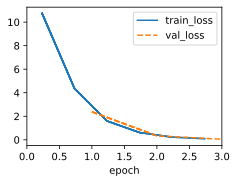

In [92]:
model = LinearRegressionScratch(2, lr=0.03)
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
trainer = d2l.Trainer(max_epochs=3)
trainer.fit(model, data)

In [93]:
with torch.no_grad():
    print(f'error in estimating w: {data.w - model.w.reshape(data.w.shape)}')
    print(f'error in estimating b: {data.b - model.b}')


error in estimating w: tensor([ 0.1224, -0.1738])
error in estimating b: tensor([0.2357])


Now follows the concise implementation

In [94]:
class LinearRegressionConcise(d2l.Module):
  def __init__(self,lr):
    super().__init__()
    self.save_hyperparameters()
    self.net = nn.LazyLinear(1) #lazylinear takes only the output dim and not input
    self.net.weight.data.normal_(0,0.01) #mean of 0 and sd=0.01
    self.net.bias.data.fill_(0)

  def forward(self,X):
    return self.net(X)

  def loss(self,y_hat,y):
    # fn = nn.MSELoss()
    fn = nn.HuberLoss()
    return fn(y_hat,y)

  def configure_optimizers(self):
    return torch.optim.SGD(self.parameters(),lr=self.lr)

  def get_w_b(self):
    return (self.net.weight.data, self.net.bias.data)


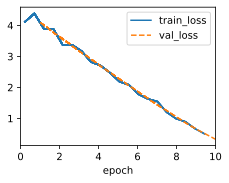

In [95]:
model = LinearRegressionConcise(lr=0.02)
data =  SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)

In [96]:
w,b = model.get_w_b()

print(f'error in estimating w: {data.w - w.reshape(data.w.shape)}')
print(f'error in estimating b: {data.b - b}')


error in estimating w: tensor([ 0.2479, -0.6062])
error in estimating b: tensor([0.5641])


It's better to increase data logarithmically because small amounts of data show big changes, and large amounts of data don’t. Log steps help you see those changes clearly without wasting time.

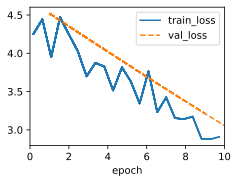

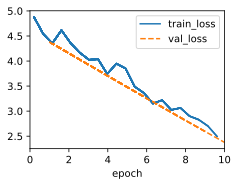

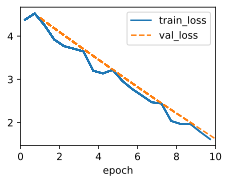

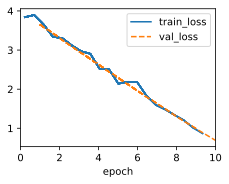

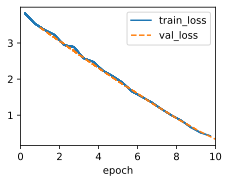

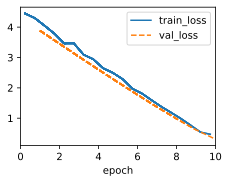

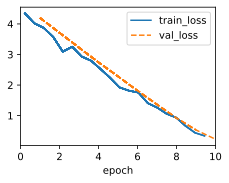

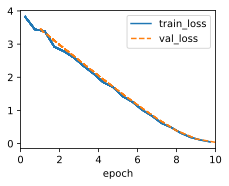

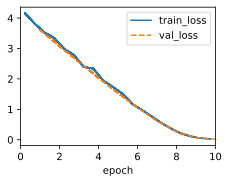

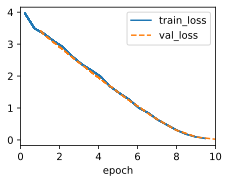

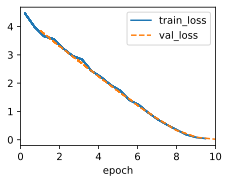

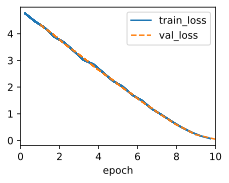

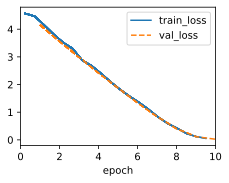

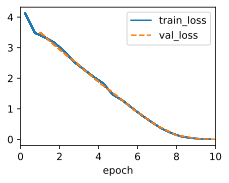

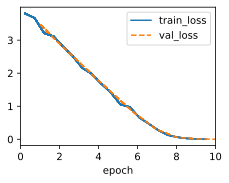

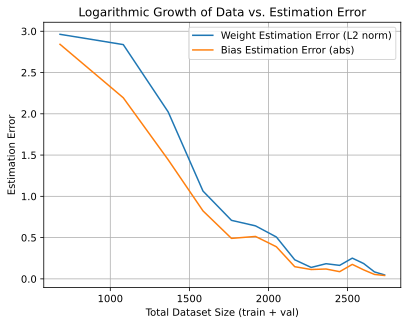

In [97]:
import math
import matplotlib.pyplot as plt

# Track dataset sizes and corresponding errors
dataset_sizes = []
w_errors = []
b_errors = []

# Logarithmic growth parameters
steps = 15  # Number of experiments
base_size = 200  # Base data size multiplier
log_base = 1.5  # How fast the size grows

true_w = torch.tensor([2, -3.4])
true_b = 4.2

for step in range(1, steps + 1):
    # Compute dataset size logarithmically
    size = int(base_size * math.log(step + 1, log_base))
    dataset_sizes.append(size * 2)  # total samples = train + val

    # Generate synthetic data
    data = SyntheticRegressionData(w=true_w, b=true_b,
                                    num_train=size, num_val=size,
                                    batch_size=32)

    # Train concise model
    model = LinearRegressionConcise(lr=0.02)
    trainer = d2l.Trainer(max_epochs=10)
    trainer.fit(model, data)

    # Get learned parameters
    w_hat, b_hat = model.get_w_b()

    # Compute estimation errors
    w_error = torch.norm(true_w - w_hat.reshape_as(true_w)).item()
    b_error = abs(true_b - b_hat.item())

    # Store errors
    w_errors.append(w_error)
    b_errors.append(b_error)

# Plotting the errors
plt.figure()
plt.plot(dataset_sizes, w_errors, label='Weight Estimation Error (L2 norm)')
plt.plot(dataset_sizes, b_errors, label='Bias Estimation Error (abs)')
plt.xlabel('Total Dataset Size (train + val)')
plt.ylabel('Estimation Error')
plt.title('Logarithmic Growth of Data vs. Estimation Error')
plt.legend()
plt.grid(True)
plt.show()


From the plot we can show that as the data-size increase the estimation error decreases and then at one point it reaches saturation.

**LETS LEARN WEIGHT DECAY**

what the Data class does is:


```
y=0.05+i=(1∑200​) 0.01xi​+ϵ,ϵ∼N(0,0.01)
```


is mimic this, to generate over-fitting prone data;

But why is it overprone fitting because, higher dimension - 200 in this case and lower training-example.

which makes the model memorize the values and thus overfitting the data.

In [105]:
class Data(d2l.DataModule):
    def __init__(self, num_train, num_val, num_inputs, batch_size,sampler=True):
        self.save_hyperparameters()
        n = num_train + num_val
        self.X = torch.randn(n, num_inputs)
        noise = torch.randn(n, 1) * 0.01
        w, b = torch.ones((num_inputs, 1)) * 0.01, 0.05 # w is 0.01 in the eq
        self.y = torch.matmul(self.X, w) + b + noise

    def get_dataloader(self, train):
        i = slice(0, self.num_train) if train else slice(self.num_train, None)
        return self.get_tensorloader([self.X, self.y], train, i)


In [106]:
def l2_penalty(w):
  return (w**2).sum()/2 #The L2 norm penalty is often written as 1/2*(w**2).sum()
  #purely for mathematical convenience, because its gradient becomes w, not 2w.

class WeightDecayScratch(LinearRegressionScratch):
    def __init__(self, num_inputs, lambd, lr, sigma=0.01):
        super().__init__(num_inputs, lr, sigma)
        self.save_hyperparameters()

    def loss(self, y_hat, y):
        return (super().loss(y_hat, y) +
                self.lambd * l2_penalty(self.w))


In [107]:
data = Data(num_train=20, num_val=100, num_inputs=200, batch_size=5)
trainer = d2l.Trainer(max_epochs=10)

def train_scratch(lambd):
    model = WeightDecayScratch(num_inputs=200, lambd=lambd, lr=0.01)
    model.board.yscale='log'
    trainer.fit(model, data)
    print('L2 norm of w:', float(l2_penalty(model.w)))


L2 norm of w: 0.00931461900472641


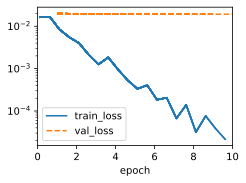

In [108]:
train_scratch(lambd=0) #without using weight decay

L2 norm of w: 0.001812945120036602


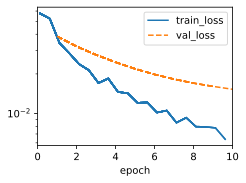

In [102]:
train_scratch(lambd=3) #using weight decay

**PURE PYTORCHIC WAY TO WRITE LINEAR REGRESSION**

In [114]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# 1. Generate synthetic data
def generate_data(num_train=1000, num_val=200, num_features=2):
    n = num_train + num_val
    X = torch.randn(n, num_features)

    # True weights and bias
    true_w = torch.tensor([[2.0], [-3.4]])
    true_b = 4.2

    y = X @ true_w + true_b
    y += 0.01  # Add noise

    # Split train/val
    X_train, X_val = X[:num_train], X[num_train:]
    y_train, y_val = y[:num_train], y[num_train:]
    return X_train, y_train, X_val, y_val


# 2. Define model
class LinearRegression(nn.Module):
    def __init__(self, lr=0.1):
        super().__init__()
        self.lr = lr
        self.net = nn.LazyLinear(1)
        self.net.weight.data.normal_(0, 0.01)
        self.net.bias.data.fill_(0)

        self.loss_fn = nn.HuberLoss()
        self.optimizer = torch.optim.SGD(self.parameters(), lr=self.lr,weight_decay=3)

    def forward(self, X):
        return self.net(X)

    def loss(self, y_hat, y):
        return self.loss_fn(y_hat, y)

    def get_optimizer(self):
        return self.optimizer

    def get_w_b(self):
        return self.net.weight.data, self.net.bias.data

# 3. Prepare data
# X_train, y_train, X_val, y_val = generate_data()
# train_ds = TensorDataset(X_train, y_train)
# val_ds = TensorDataset(X_val, y_val)

data = Data(num_train=20, num_val=100, num_inputs=200, batch_size=5)
train_ds = data.train_dataloader()
val_ds = data.val_dataloader()

train_loader = train_ds
val_loader = val_ds



# 4. Train the model
model = LinearRegression(lr=0.01)
optimizer = model.get_optimizer()

train_losses = []
val_losses = []

num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    train_loss_sum = 0
    train_batches = 0

    for X_batch, y_batch in train_loader:
        y_hat = model(X_batch)
        loss = model.loss(y_hat, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()
        train_batches += 1

    avg_train_loss = train_loss_sum / train_batches
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss_sum = 0
    val_batches = 0
    with torch.no_grad():
        for X_val_batch, y_val_batch in val_loader:
            y_val_pred = model(X_val_batch)
            val_loss = model.loss(y_val_pred, y_val_batch)
            val_loss_sum += val_loss.item()
            val_batches += 1

    avg_val_loss = val_loss_sum / val_batches
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

# 5. Final weights and bias
w, b = model.get_w_b()
print("Learned weights:", w)
print("Learned bias:", b)


Epoch 1: Train Loss = 0.1918, Val Loss = 0.1384
Epoch 2: Train Loss = 0.0565, Val Loss = 0.1092
Epoch 3: Train Loss = 0.0181, Val Loss = 0.0874
Epoch 4: Train Loss = 0.0068, Val Loss = 0.0705
Epoch 5: Train Loss = 0.0036, Val Loss = 0.0573
Epoch 6: Train Loss = 0.0022, Val Loss = 0.0469
Epoch 7: Train Loss = 0.0018, Val Loss = 0.0387
Epoch 8: Train Loss = 0.0012, Val Loss = 0.0322
Epoch 9: Train Loss = 0.0013, Val Loss = 0.0271
Epoch 10: Train Loss = 0.0010, Val Loss = 0.0231
Epoch 11: Train Loss = 0.0010, Val Loss = 0.0199
Epoch 12: Train Loss = 0.0011, Val Loss = 0.0175
Epoch 13: Train Loss = 0.0010, Val Loss = 0.0156
Epoch 14: Train Loss = 0.0011, Val Loss = 0.0140
Epoch 15: Train Loss = 0.0010, Val Loss = 0.0128
Epoch 16: Train Loss = 0.0010, Val Loss = 0.0118
Epoch 17: Train Loss = 0.0009, Val Loss = 0.0111
Epoch 18: Train Loss = 0.0010, Val Loss = 0.0105
Epoch 19: Train Loss = 0.0009, Val Loss = 0.0100
Epoch 20: Train Loss = 0.0010, Val Loss = 0.0096
Epoch 21: Train Loss = 0.0011

In [115]:
for params in model.parameters():
  print(params)

Parameter containing:
tensor([[ 1.3240e-04, -3.9827e-03,  2.0550e-03,  4.7166e-03, -2.1659e-03,
          2.6019e-03,  1.6669e-03,  2.6542e-03, -1.1782e-03,  3.7791e-03,
          2.6007e-03, -2.9761e-03,  3.2515e-03,  4.9024e-03, -2.1771e-03,
         -4.6650e-03,  4.7903e-03,  7.7144e-04,  1.8849e-03,  6.0318e-03,
         -1.9151e-03,  7.8632e-04,  2.7803e-03,  3.6206e-03, -2.0400e-04,
          1.3817e-03, -5.5473e-03,  6.8923e-04, -3.5320e-03,  3.4326e-03,
          1.5614e-03,  8.3318e-04,  7.4877e-04,  3.0967e-03,  1.8256e-03,
          8.0439e-04,  6.8990e-03,  1.4976e-03,  1.1044e-03,  4.0319e-03,
         -1.1278e-03, -6.2002e-04,  2.9400e-03,  1.0614e-03,  1.3335e-03,
         -2.0034e-04,  5.2092e-03, -1.4612e-03,  4.0194e-03, -4.0202e-04,
          4.5991e-03,  4.5364e-04, -2.0373e-03,  3.0154e-03,  8.2438e-04,
          2.8784e-03, -3.6258e-03,  1.3011e-04, -5.7072e-04,  1.0678e-03,
         -1.3787e-03,  5.8757e-03, -4.5354e-04,  1.5227e-03,  5.7624e-03,
          3.8098

/tmp/ipython-input-2114274887.py:36: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


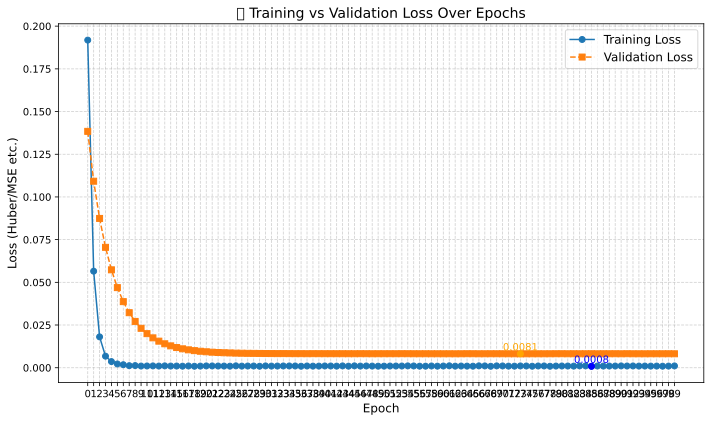

In [116]:
import matplotlib.pyplot as plt

# Set figure size
plt.figure(figsize=(10, 6))

# Plot training and validation loss
plt.plot(train_losses, label='Training Loss', marker='o', linestyle='-')
plt.plot(val_losses, label='Validation Loss', marker='s', linestyle='--')

# Annotate min loss points
min_train_epoch = train_losses.index(min(train_losses))
min_val_epoch = val_losses.index(min(val_losses))

plt.scatter(min_train_epoch, train_losses[min_train_epoch], color='blue', zorder=5)
plt.scatter(min_val_epoch, val_losses[min_val_epoch], color='orange', zorder=5)

plt.text(min_train_epoch, train_losses[min_train_epoch] + 0.002,
         f'{train_losses[min_train_epoch]:.4f}',
         color='blue', ha='center')

plt.text(min_val_epoch, val_losses[min_val_epoch] + 0.002,
         f'{val_losses[min_val_epoch]:.4f}',
         color='orange', ha='center')

# Titles and labels
plt.title('📈 Training vs Validation Loss Over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Huber/MSE etc.)', fontsize=12)

# Ticks and grid
plt.xticks(range(len(train_losses)))
plt.grid(True, linestyle='--', alpha=0.6)

# Legend
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
